# **Explainable Mobile Price Intelligence System**

**Import Libraries**

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix)


In [43]:
from google.colab import files
uploaded = files.upload()

Saving mobile_prices.csv to mobile_prices (1).csv


# **Data Collection & Exploration**

In [44]:
data = pd.read_csv('mobile_prices.csv')
data.head(6)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1
5,1859,0,0.5,1,3,0,22,0.7,164,1,...,1004,1654,1067,17,1,10,1,0,0,1


In [45]:
data.shape

(2000, 21)

In [46]:
data.columns.tolist()

['battery_power',
 'blue',
 'clock_speed',
 'dual_sim',
 'fc',
 'four_g',
 'int_memory',
 'm_dep',
 'mobile_wt',
 'n_cores',
 'pc',
 'px_height',
 'px_width',
 'ram',
 'sc_h',
 'sc_w',
 'talk_time',
 'three_g',
 'touch_screen',
 'wifi',
 'price_range']

In [47]:
data.duplicated().sum()   # No duplicate values
data = data.dropna()
data.isnull().sum()    # No missing values

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [48]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


## **EDA**

**Correlation Analysis**

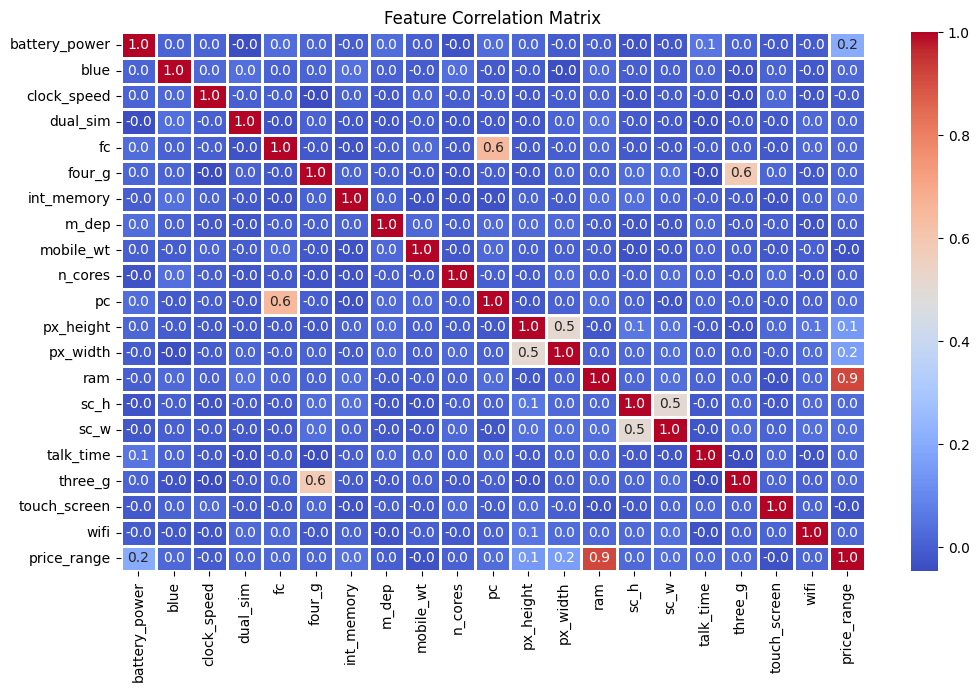

In [49]:
plt.figure(figsize=(12, 7))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.1f',
            linewidths=1)
plt.title('Feature Correlation Matrix')
plt.show()

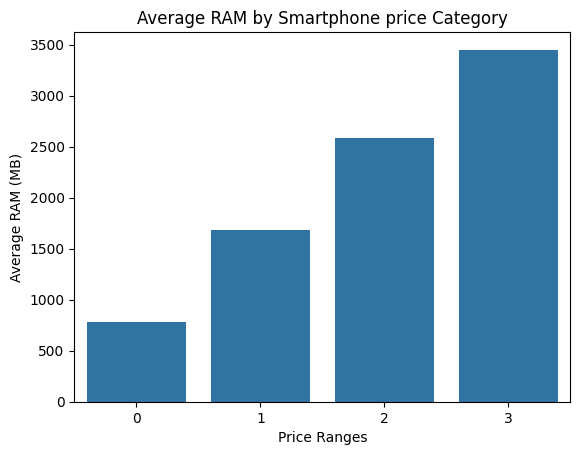

<Figure size 900x500 with 0 Axes>

In [50]:
ram_by_price = data.groupby('price_range')['ram'].mean()
sns.barplot(
    x = ram_by_price.index,
    y = ram_by_price.values
)

plt.xlabel('Price Ranges')
plt.ylabel('Average RAM (MB)')
plt.title('Average RAM by Smartphone price Category')
plt.figure(figsize=(9,5))
plt.show()


**Feature Enggineering**

In [51]:
data_copy = data.copy()     # Taking the copy of original dataset for feature enggineering
# Calculating total screen resolution as height * width
data_copy['screen_resolution'] = (
    data_copy['px_height'] * data_copy['px_width']
)
# Calculating screen aspect ratio while protecting against div by zero
data_copy['screen_aspect_ratio'] = (
    data_copy['px_width'] / data_copy['px_height'].replace(0, np.nan)
)
# Calculating total camera capability by combining front and pimary cameras
data_copy['total_camera'] = (
    data_copy['fc'] + data_copy['pc']
)
# Creating a processor capability proxy using core count and clock speed
data_copy['cpu_performance_proxy'] = (
    data['n_cores'] * data_copy['clock_speed']
)

display(data_copy[['screen_resolution', 'screen_aspect_ratio','total_camera','cpu_performance_proxy']].head())


,screen_resolution,screen_aspect_ratio,total_camera,cpu_performance_proxy
0,15120,37.800000,3,4.4
1,1799140,2.196685,6,1.5
2,2167308,1.358670,8,2.5
3,2171776,1.468750,9,15.0
4,1464096,1.003311,27,2.4


# **Model Building & Training**
**Data Preperation**

In [52]:
x = data_copy.drop(columns=['price_range'])
y = data_copy['price_range']
print('Features/independent Variables Shape',x.shape)
print('Target/Dependent Variables Shape',y.shape)

Features/independent Variables Shape (2000, 24)
Target/Dependent Variables Shape (2000,)


In [53]:
x_train, x_test, y_train, y_test = train_test_split(
  x,
  y,
  test_size=0.2,
  stratify=y,
  random_state=42
)
print('x_train: ',x_train.shape)
print('y_train: ',y_train.shape)
print('x_test: ',x_test.shape)
print('y_test: ',y_test.shape)

x_train:  (1600, 24)
y_train:  (1600,)
x_test:  (400, 24)
y_test:  (400,)


Lets train Logistic Regression and visualize what results it produces before diving into training other models

In [54]:
# Creating a pipeline that scales the features and then trains logistic regression
logistic_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=5000, random_state=42))
])
logistic_pipeline.fit(x_train, y_train)
logistic_predictions = logistic_pipeline.predict(x_test)
logistic_predictions[:10]

array([3, 1, 0, 2, 3, 2, 0, 0, 1, 0])


Training Several Models

In [55]:
models = {
    # Logistic Regression Classifier
    'Logistic Regression':Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # Replacing missing values with median value of that column
        ('scaler', StandardScaler()),             # Standardize the input features
        ('model', LogisticRegression(max_iter=5000, random_state=42)) # Train linear classifier with 5000 passses for convergence
    ]),
    # Decision Tree Classifier
    'Decision Tree':Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # Replacing missing values with median value of that column
        ('model', DecisionTreeClassifier(random_state=42))   # Train decision Tree classifier
    ]),
    # Random Forest Classifier
    'Random Forest': Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # Replacing missing values with median value of that column
        ('model', RandomForestClassifier(  # Train random forest
            n_estimators=300,  # Build 300 decision trees
            random_state=42,
            n_jobs=-1))  # Use all available CPU cores
    ]),
    # Extra Trees Classifier
    'Extra Trees': Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # Replacing missing values with median value of that column
        ('model', ExtraTreesClassifier(  # Train Extra Trees
            n_estimators=300, # Build 300 randomized trees
            random_state=42,
            n_jobs=-1))   # Use all avail CPU cores
    ]),
    # Gradient Boosting Classifier
    'Gradient Boosting':Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # Replacing missing values with median value of that column
        ('model', GradientBoostingClassifier(random_state=42))
    ]),
    # SVM (Support Vector Machine)
    'SVM':Pipeline([
        ('imputer', SimpleImputer(strategy='median')), # Replacing missing values with median value of that column
        ('model', SVC(probability=True,  # Train SVM and enable probability estimates
                      random_state=42))
    ])
}
print('Models to be Evaluated:')
for model_name, model in models.items():
  print('->',model_name)

Models to be Evaluated:
-> Logistic Regression
-> Decision Tree
-> Random Forest
-> Extra Trees
-> Gradient Boosting
-> SVM


In [56]:
model_results = []
for model_name, model in models.items():
  model.fit(x_train, y_train)  # Training model with training dataset
  predictions = model.predict(x_test)  # Generate predictions for unseen test dataset
  accuracy = accuracy_score(y_test, predictions)   # Calculate accuracy
  precision = precision_score(y_test, predictions, average='macro')  # Calculate macro precision across all price categories
  recall = recall_score(y_test, predictions, average='macro')  # Calculate macro reacll across all price categories
  f1 = f1_score(y_test, predictions, average='macro')  # Calculate macro f1 score

  # Store evaluation results
  model_results.append({
      'Model':model_name,
      'Accuracy' : accuracy,
      'Macro Precision':precision,
      'Macro Recall':recall,
      'Macro F1': f1
  })

results_data = pd.DataFrame(model_results)
results_data = results_data.sort_values(
    'Macro F1',
    ascending=False,
).reset_index(drop=True)
display(results_data)

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Logistic Regression,0.9650,0.965146,0.9650,0.964919
1,Gradient Boosting,0.9175,0.917960,0.9175,0.917552
2,Random Forest,0.8900,0.889457,0.8900,0.889203
3,Decision Tree,0.8850,0.887123,0.8850,0.885245
4,Extra Trees,0.8850,0.884211,0.8850,0.882789
5,SVM,0.3175,0.231667,0.3175,0.252715


###**K-Fold Cross-Validation**

We will use 5-fold stratified cross-validation. The training data is divided into five parts. Each fold becomes the validation set once while the remaining four folds are used for training.

In [57]:
cv = StratifiedKFold(
    n_splits=5,    # Divide the training data into five folds
    shuffle=True,   # Shuffle observations before creating folds
    random_state=42
)
scoring = {
    'accuracy':'accuracy',
    'precision':'precision_macro',
    'recall':'recall_macro',
    'f1':'f1_macro'
}

cv_results = []
for model_name, model in models.items():
  scores = cross_validate(
      model,       # Model being evaluated
      x_train,     # Training features
      y_train,     # Training Target
      cv=cv,       # Five-fold stratified CV
      scoring=scoring,  # Evaluation metrics
      n_jobs=-1    # Use all available CPU cores
  )

  cv_results.append({
      'Model':model_name,
      'CV Accuracy Mean':scores['test_accuracy'].mean(),  # Calculate accuracy mean
      'CV Accuracy Std': scores['test_accuracy'].std(),   # Calculate Accuracy variabllity
      'CV Macro F1 Mean': scores['test_f1'].mean(),       # Calculate mean macro f1
      'CV Macro F1 Std':scores['test_f1'].std(),          # Calculate macro f1 variability
      'CV Precision Mean':scores['test_precision'].mean(),   # Calculate Precision mean
      'CV Recall Mean':scores['test_recall'].mean()     # Calculate Recall mean
      })

cv_results_data = pd.DataFrame(cv_results)
cv_results_data = cv_results_data.sort_values(
    'CV Macro F1 Mean',   # Sorting the models by mean CV macro F1 descending
    ascending=False,

).reset_index(drop=True)

display(cv_results_data)


,Model,CV Accuracy Mean,CV Accuracy Std,CV Macro F1 Mean,CV Macro F1 Std,CV Precision Mean,CV Recall Mean
0,Logistic Regression,0.948125,0.013778,0.947952,0.013790,0.948564,0.948125
1,Gradient Boosting,0.895000,0.025357,0.895168,0.024948,0.896424,0.895000
2,Random Forest,0.862500,0.020540,0.862186,0.020475,0.863420,0.862500
3,Extra Trees,0.856250,0.013405,0.855195,0.013793,0.856513,0.856250
4,Decision Tree,0.832500,0.014604,0.832471,0.013759,0.833614,0.832500
5,SVM,0.290000,0.022742,0.231704,0.021723,0.212619,0.290000


CV Macro F1 = 0.94795 ± 0.01379
Logistic Regression isn't just performing well on one lucky split; it is performing consistently well across the five folds

In [58]:
# Select the name of the model with highest mean CV Macro F1 Score
best_model_name = cv_results_data.loc[
    cv_results_data['CV Macro F1 Mean'].idxmax(),
    'Model'
]
best_model = models[best_model_name]
print(f'Best Model: {best_model_name}')
best_model_cv = cv_results_data[cv_results_data['Model'] == best_model_name]

Best Model: Logistic Regression


In [59]:
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)
print('Final Model:',best_model_name)
print('Model trained Successfully')

Final Model: Logistic Regression
Model trained Successfully


**test-set evaluation**

In [60]:
test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(
    y_test,
    y_pred,
    average='macro'
)
test_recall = recall_score(
    y_test,
    y_pred,
    average='macro'
)
test_f1 = f1_score(
    y_test,
    y_pred,
    average='macro'
)

print('Final Test Set Performance')
print('-'*25)
print(f'Accuracy:{test_accuracy: .4f}')
print(f'Precision:{test_precision: .4f}')
print(f'Recall:{test_recall: .4f}')
print(f'F1 Score:{test_f1: .4f}')

Final Test Set Performance
-------------------------
Accuracy: 0.9650
Precision: 0.9651
Recall: 0.9650
F1 Score: 0.9649


In [61]:
print(classification_report(
    y_test,
    y_pred,
    target_names=[
        'Low Price',
        'Medium Price',
        'High Price',
        'Very High Price'
    ]
))

                 precision    recall  f1-score   support

      Low Price       0.99      0.98      0.98       100
   Medium Price       0.96      0.96      0.96       100
     High Price       0.96      0.93      0.94       100
Very High Price       0.95      0.99      0.97       100

       accuracy                           0.96       400
      macro avg       0.97      0.97      0.96       400
   weighted avg       0.97      0.96      0.96       400



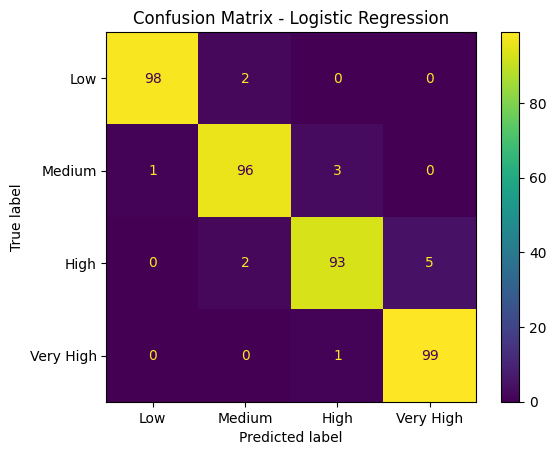

In [62]:
from sklearn.metrics import ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Low','Medium','High','Very High']
)
disp.plot()
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()

**Explanation of above Confusion Matrix**
- Low: Out of 100 actual Low cases, **98 were correctly** classified as Low. **Only 2 were incorrectly** classified as Medium.
- Medium: Out of 100 actual Medium cases, **96 were correctly** classified as Medium. **1** was classified as Low and **3 as High**.
- High: Out of 100 actual High cases, **93 were correctly** classified as High. **2 were classified as Medium** and **5 as Very High**.
- Very High: Out of 100 actual Very High cases, **99 were correctly** classified as Very High. Only **1 was classified as High**.




# **Prediction**

In [63]:
# The final model can be used to predict the price category of a new mobile phone based on its technical specifications.
# The system accepts the same features used during model training and returns one of four price categories.
price_labels = {
    0:'Low Price',
    1:'Medium Price',
    2:'High Price',
    3:'Very High Price',
}
# Function for predicting the price category
def predict_mobile_price(mobile_data):
  input_data = pd.DataFrame([mobile_data])   # Convert mobile deets into a DataFrame
  input_data = input_data[x_train.columns]  # Arrange the input data columns in correct order
  prediction = best_model.predict(input_data)[0] # Predict the price category
  probabilities = best_model.predict_proba(input_data)[0] # generate probabilities for every price category
  confidence = probabilities[prediction]  # Get the probability of the predicted class
  predicted_category = price_labels[prediction]  # Converting prediction into readable category (i.e Low, High etc...)
  return predicted_category, confidence, probabilities

In [64]:
# Creating specification for an example smartphone
example_mobile = {
    'battery_power':1500,
    'blue':1,
    'clock_speed':1.5,
    'dual_sim':1,
    'fc':4,
    'four_g':1,
    'int_memory':32,
    'm_dep': 0.5,
    'mobile_wt': 150,
    'n_cores': 4,
    'pc': 8,
    'px_height':1000,
    'px_width':1800,
    'ram':3000,
    'sc_h':15,
    'sc_w':8,
    'talk_time':15,
    'three_g':1,
    'touch_screen':1,
    'wifi':1,
    'screen_resolution':1800000,
    'screen_aspect_ratio':1.8,
    'total_camera':12,
    'cpu_performance_proxy':6.0
}
prediction, confidence, probabilities = predict_mobile_price(example_mobile)
print(f'Pedicted Price Category: {prediction}')
print(f'Model Confidence: {confidence: .2%}')

print('\nPrice Category Probabilities:')

print(f'Low Price: {probabilities[0]: .2%}')
print(f'Medium Price: {probabilities[1]: .2%}')
print(f'High Price: {probabilities[2]: .2%}')
print(f'Very High Price: {probabilities[3]: .2%}')

Pedicted Price Category: Very High Price
Model Confidence:  96.98%

Price Category Probabilities:
Low Price:  0.00%
Medium Price:  0.00%
High Price:  3.02%
Very High Price:  96.98%


**What-if Analysis**

In [65]:
# We trying to answer this question:
# "What happens to the predicted price range if we increase RAm?"
ram_values = [200, 500, 800, 1000, 2000, 4000]
what_if_results = []

for ram_value in ram_values:
  modified_mobile = example_mobile.copy()
  modified_mobile['ram'] = ram_value
  predicted_price = predict_mobile_price(modified_mobile)

  what_if_results.append({
      'RAM':ram_value,
      'Predicted Price Category':predicted_price[0]
  })
what_if_df = pd.DataFrame(what_if_results)
display(what_if_df)

,RAM,Predicted Price Category
0,200,Low Price
1,500,Low Price
2,800,Medium Price
3,1000,Medium Price
4,2000,High Price
5,4000,Very High Price


# **Explainable Mobile Price Intelligence System**
# **Project Summary**
This project builds a **Machine Learning model to classify smartphones into four price categories** based on their technical specifications. The workflow includes exploratory data analysis, feature engineering, preprocessing, multiple classification models, cross-validation, model evaluation, and prediction for new smartphones.

## **Dataset Overview**

The dataset contains **2,000 smartphone records** with specifications such as RAM, battery power, camera, screen resolution, processor information, connectivity, and price range.

| Feature                 | Description               |
| ----------------------- | ------------------------- |
| `battery_power`         | Battery capacity          |
| `ram`                   | RAM of the smartphone     |
| `px_height`, `px_width` | Screen resolution         |
| `fc`, `pc`              | Front and primary camera  |
| `clock_speed`           | Processor clock speed     |
| `n_cores`               | Number of processor cores |
| `int_memory`            | Internal memory           |
| `mobile_wt`             | Mobile weight             |
| `talk_time`             | Battery talk time         |
| `price_range`           | Target price category     |

The target variable contains four categories: **Low, Medium, High, and Very High Price**.

## **Project Workflow**

### 1. Exploratory Data Analysis

A **feature correlation matrix** was created to understand relationships between numerical features. The project also analyzes the average RAM across the four smartphone price categories.

### 2. Feature Engineering

Four additional features were created:

* **Screen Resolution** = `px_height × px_width`
* **Screen Aspect Ratio** = `px_width / px_height`
* **Total Camera** = `fc + pc`
* **CPU Performance Proxy** = `n_cores × clock_speed`

These features provide additional information that may help the classification models.

### 3. Data Preparation

The data was divided into:

* **80% training:** 1,600 records
* **20% testing:** 400 records


Missing values are handled using **median imputation**, and Logistic Regression uses **StandardScaler** for feature standardization.

### 4. Model Training

Six classification models were evaluated:

* Logistic Regression
* Decision Tree
* Random Forest
* Extra Trees
* Gradient Boosting
* Support Vector Machine (SVM)

### 5. Cross-Validation

A **5-fold Stratified Cross-Validation** was used to obtain a more reliable estimate of model performance. Models were primarily compared using **Macro F1-Score**.

## Model Performance

| Model                   | CV Accuracy | CV Macro F1 |
| ----------------------- | ----------: | ----------: |
| **Logistic Regression** |  **94.81%** |  **94.80%** |
| Gradient Boosting       |      89.50% |      89.52% |
| Random Forest           |      86.25% |      86.22% |
| Extra Trees             |      85.63% |      85.52% |
| Decision Tree           |      83.25% |      83.25% |
| SVM                     |      29.00% |      23.17% |

Based on the mean CV Macro F1 score, **Logistic Regression** was selected as the final model.

## Final Model Evaluation

On the 400-record test set, the final model achieved approximately:

* **Accuracy:** 96%
* **Macro Precision:** 97%
* **Macro Recall:** 97%
* **Macro F1:** 96%

| Price Category  | Precision | Recall | F1-Score |
| --------------- | --------: | -----: | -------: |
| Low Price       |      0.99 |   0.98 |     0.98 |
| Medium Price    |      0.96 |   0.96 |     0.96 |
| High Price      |      0.96 |   0.93 |     0.94 |
| Very High Price |      0.95 |   0.99 |     0.97 |

## New Smartphone Prediction

A custom `predict_mobile_price()` function was created to predict the price category of a new smartphone.

The function returns:

* Predicted price category
* Model confidence
* Probability for each price category

A **what-if analysis** was also performed by changing the RAM value of an example smartphone to observe how the predicted price category changes.

## **Conclusion**

This project demonstrates an end-to-end **smartphone price classification system** using machine learning. Feature engineering, multiple classification algorithms, and 5-fold cross-validation were used to build and evaluate the models. **Logistic Regression achieved the highest cross-validation Macro F1 of 94.80%**, while the final test evaluation achieved approximately **96% accuracy and 96% Macro F1**. The completed system can also classify new smartphones and perform simple specification-based what-if analysis.
